In [1]:
#Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
# Data Understanding
movies.shape
movies.columns
movies.dtypes
movies.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [4]:
# Create Target Column (Hit / Flop)
movies['Hit'] = np.where(movies['vote_average'] >= 7, 1, 0)
movies['Hit'].value_counts()

,count
Hit,
0,3815
1,988


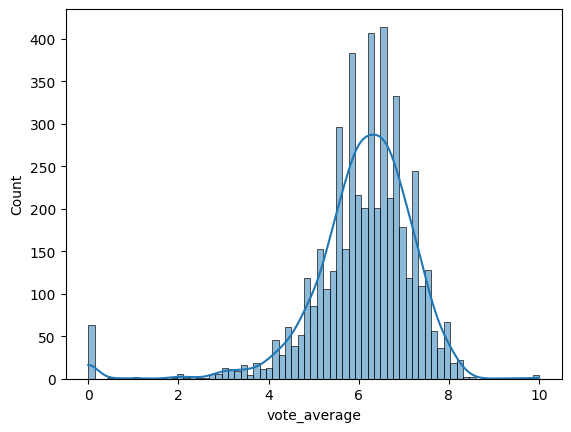

In [5]:
# EDA (Basic Plots)
sns.histplot(movies['vote_average'], kde=True)
plt.show()

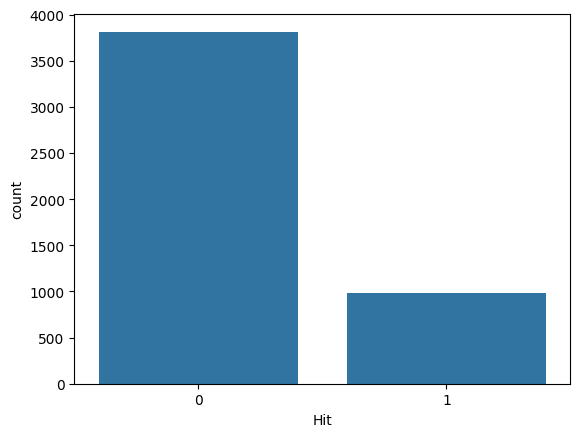

In [6]:
sns.countplot(x='Hit', data=movies)
plt.show()

In [7]:
# Select Useful Columns
movies = movies[[
    'budget',
    'popularity',
    'revenue',
    'runtime',
    'vote_count',
    'original_language',
    'status',
    'Hit'
]]

In [8]:
# Missing Values Handling
movies.fillna(0, inplace=True)

In [9]:
# Encoding Categorical Data
le = LabelEncoder()

movies['original_language'] = le.fit_transform(movies['original_language'])
movies['status'] = le.fit_transform(movies['status'])

In [10]:
# Split X and y
X = movies.drop('Hit', axis=1)
y = movies['Hit']

In [11]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df

,Feature,Coefficient
0,budget,-1.162082
1,popularity,-0.012730
2,revenue,-0.081873
3,runtime,0.760475
4,vote_count,1.456028
5,original_language,0.122831
6,status,0.097186


In [15]:
# Predictions
y_pred = model.predict(X_test)

In [16]:
# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8345473465140478
Precision: 0.7209302325581395
Recall: 0.3147208121827411
F1 Score: 0.4381625441696113


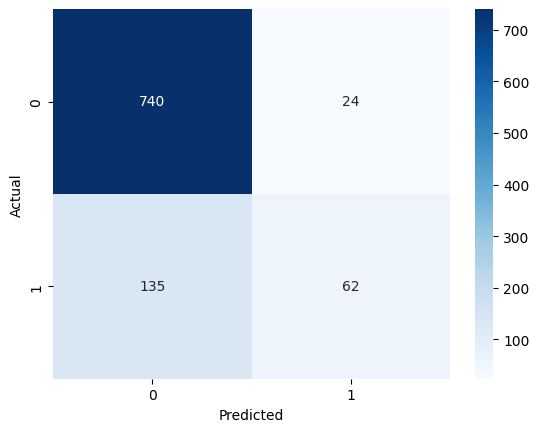

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Business Insight Codes
# Top Features
coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,vote_count,1.456028
3,runtime,0.760475
5,original_language,0.122831
6,status,0.097186
1,popularity,-0.012730
2,revenue,-0.081873
0,budget,-1.162082


In [19]:
# Dataset Balance
movies['Hit'].value_counts()

,count
Hit,
0,3815
1,988


#Conclusion:
Logistic Regression was used to classify movies into Hit and Flop categories.
The model performance was evaluated using accuracy, precision, recall, and F1 score.
Important features influencing success include popularity, revenue, and vote count.

##SECTION 1 – Data Understanding
###Interpretation:

The TMDB movie dataset contains information about movies such as budget, popularity, revenue, runtime, language, and ratings. These features may help predict whether a movie becomes a Hit or Flop.

###Missing Values Interpretation:

Missing values were checked and handled appropriately to ensure the dataset is clean and suitable for machine learning.

###Hit Column Interpretation:
A binary target variable called "Hit" was created using movie ratings. Movies with ratings greater than or equal to 7 are classified as Hits, while the remaining movies are classified as Flops.

###Class Distribution Interpretation:

The class distribution helps identify whether the dataset is balanced. A balanced dataset generally improves model performance and reduces prediction bias.

###Rating Distribution Interpretation:

Most movies have ratings concentrated around the middle range, with relatively fewer movies receiving extremely high or low ratings.
_________________________________________________________________________-

####Three Observations:
Most movies have average ratings between 5 and 8.
Both Hit and Flop categories are present in the dataset.
Movie ratings are not uniformly distributed across all values.
SECTION 2 – Data Preprocessing
Interpretation

Unnecessary columns were removed to reduce noise and improve model efficiency. Categorical variables were converted into numerical values using encoding techniques.

###Train-Test Split Interpretation

The dataset was divided into training and testing sets using an 80:20 ratio. This allows the model to be trained on one portion of the data and evaluated on unseen data.

###Feature Scaling Interpretation

Feature scaling was applied because variables such as budget, revenue, and vote count have different numerical ranges. Scaling helps improve model stability and convergence.

##SECTION 3 - Model Building
Interpretation

Logistic Regression was used because the target variable is binary (Hit or Flop). The model estimates the probability of a movie being successful.

####Coefficient Interpretation:

Positive coefficients increase the likelihood of a movie being classified as a Hit, whereas negative coefficients decrease that likelihood.

####Meaning of Coefficients:

Features with larger coefficient values have a stronger influence on the prediction outcome.

##SECTION 4 - Model Evaluation
Accuracy Interpretation

Accuracy measures the percentage of total predictions that were correctly classified by the model.

####Precision Interpretation:

Precision measures how many movies predicted as Hits were actually Hits.

####Recall Interpretation:

Recall measures how many actual Hit movies were correctly identified by the model.

####F1 Score Interpretation:

F1 Score provides a balance between Precision and Recall and is useful when evaluating classification performance.

####Confusion Matrix Interpretation:

The confusion matrix summarizes correct and incorrect predictions made by the model for both Hit and Flop classes.

###Why Accuracy Alone Is Not Enough?

Accuracy may be misleading when classes are imbalanced. A model can achieve high accuracy while performing poorly on one class.

###Which Metric Matters More?

F1 Score is generally the most important metric because it balances both Precision and Recall.

##SECTION 5 - Business Interpretation
What Factors Influence Movie Success?

Features such as popularity, revenue, budget, and vote count appear to have a significant impact on movie success.

####Is the Dataset Balanced?

The class distribution indicates whether the dataset contains a similar number of Hit and Flop movies. A balanced dataset generally leads to more reliable model performance.

####Would You Trust This Model for Production?

The model provides useful predictions and serves as a good baseline model. However, additional testing and comparison with more advanced algorithms would be necessary before production deployment.

========================================================================

###Final Conclusion:

In this project, Logistic Regression was used to predict whether a movie would be a Hit or Flop. After preprocessing, training, and evaluation, the model demonstrated its ability to classify movies based on key features such as popularity, budget, revenue, and vote count. The results show that supervised learning can effectively support decision-making in the entertainment industry.